In [1]:
import torch 
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
image_path = []
labels = []

for i in os.listdir('data/'):
    for label in os.listdir(f'data/{i}'):
        for image in os.listdir(f'data/{i}/{label}'):
            image_path.append(f'data/{i}/{label}/{image}')
            labels.append(label)

In [4]:
data = pd.DataFrame(zip(image_path, labels), columns=['image_path', 'labels'])

In [5]:
train = data.sample(frac=0.7, random_state=42)
remaining = data.drop(train.index)

val = remaining.sample(frac=0.5, random_state=42)
test = remaining.drop(val.index)

In [6]:
le = LabelEncoder()
le.fit(data['labels'])
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [7]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.labels = torch.tensor(le.transform(self.dataframe['labels']), dtype=torch.long)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index, 0]
        label = self.labels[index]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [9]:
class ImageClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),  
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
num_classes = len(le.classes_)
model = ImageClassificationModel(num_classes=num_classes).to(device)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
import torch

epochs = 10

train_loss_plot = []
val_loss_plot = []
train_acc_plot = []
val_acc_plot = []

for epoch in range(epochs):
    train_loss = 0.0
    train_correct = 0

    val_loss = 0.0
    val_correct = 0

    # training
    model.train()
    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()

    # validation
    model.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()

    train_loss /= len(train_dataloader)
    val_loss /= len(val_dataloader)

    train_acc = train_correct / len(train_dataloader.dataset)
    val_acc = val_correct / len(val_dataloader.dataset)

    train_loss_plot.append(train_loss)
    val_loss_plot.append(val_loss)
    train_acc_plot.append(train_acc)
    val_acc_plot.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )
    print('=' * 30)

Epoch 1/10 | Train Loss: 0.4303 | Train Acc: 0.8204 | Val Loss: 0.2347 | Val Acc: 0.9194
Epoch 2/10 | Train Loss: 0.1539 | Train Acc: 0.9445 | Val Loss: 0.1271 | Val Acc: 0.9574
Epoch 3/10 | Train Loss: 0.0945 | Train Acc: 0.9664 | Val Loss: 0.1187 | Val Acc: 0.9599
Epoch 4/10 | Train Loss: 0.0552 | Train Acc: 0.9802 | Val Loss: 0.1871 | Val Acc: 0.9343
Epoch 5/10 | Train Loss: 0.0398 | Train Acc: 0.9850 | Val Loss: 0.1205 | Val Acc: 0.9628
Epoch 6/10 | Train Loss: 0.0266 | Train Acc: 0.9905 | Val Loss: 0.1888 | Val Acc: 0.9508
Epoch 7/10 | Train Loss: 0.0232 | Train Acc: 0.9918 | Val Loss: 0.1881 | Val Acc: 0.9525
Epoch 8/10 | Train Loss: 0.0202 | Train Acc: 0.9930 | Val Loss: 0.1386 | Val Acc: 0.9640
Epoch 9/10 | Train Loss: 0.0224 | Train Acc: 0.9921 | Val Loss: 0.2525 | Val Acc: 0.9430
Epoch 10/10 | Train Loss: 0.0111 | Train Acc: 0.9964 | Val Loss: 0.1615 | Val Acc: 0.9686


In [13]:
test_loss = 0.0
test_correct = 0

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        test_correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_dataloader)
test_acc = test_correct / len(test_dataloader.dataset)

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Test Loss: 0.1401 | Test Acc: 0.9698


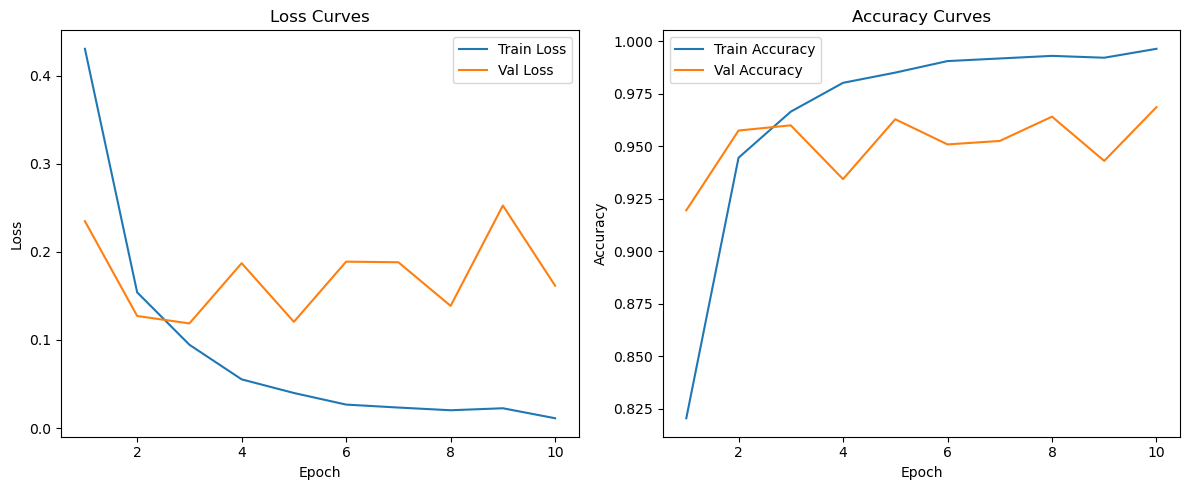

In [14]:
epochs_range = range(1, len(train_loss_plot) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_plot, label="Train Loss")
plt.plot(epochs_range, val_loss_plot, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_plot, label="Train Accuracy")
plt.plot(epochs_range, val_acc_plot, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

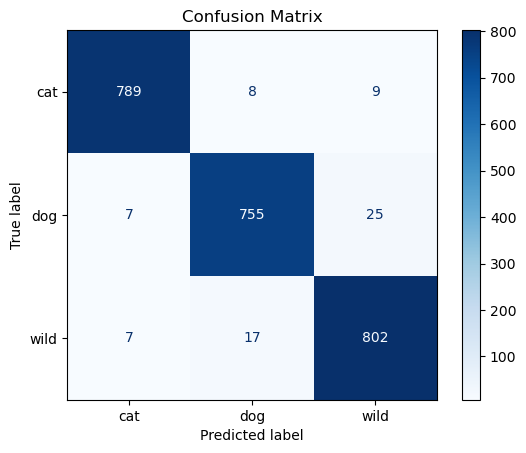

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=le.classes_))

              precision    recall  f1-score   support

         cat       0.98      0.98      0.98       806
         dog       0.97      0.96      0.96       787
        wild       0.96      0.97      0.97       826

    accuracy                           0.97      2419
   macro avg       0.97      0.97      0.97      2419
weighted avg       0.97      0.97      0.97      2419



In [17]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/image_classifier.pth")